# HDBSCAN Notebook
* This notebook will generate the visualisation seen in the Report for the *modified* TPCRP Algorithm

In [ ]:
import numpy as np 


import matplotlib.pyplot as plt 
import torchvision
import torchvision.transforms as transforms

from sklearn.decomposition import PCA


In [ ]:

Budget = "B10"
path = f"../budget_results/modified_budget_results/hdbscan_results/typiclust_HDBSCAN_{Budget}.npy"
indices = np.load(path)

limitOfDemonstration = 20

indices[:limitOfDemonstration] # peek of path

#../TPCRP_Algorithm/budget_results/typiclust_B{B}.npy

array([ 6388, 22745, 23688, 25875, 26873, 30570, 34129, 44185, 49134,
       49859])

After initalisation of a chosen budget, the process of visualisation entails the following : 
* Plotting distribution of selected indices 
* Visualisation of actual CIFAR-10 Images (Selected by the algorithm)
* Visaulisation of choices ( selected points ) in a PCA feature manifold 

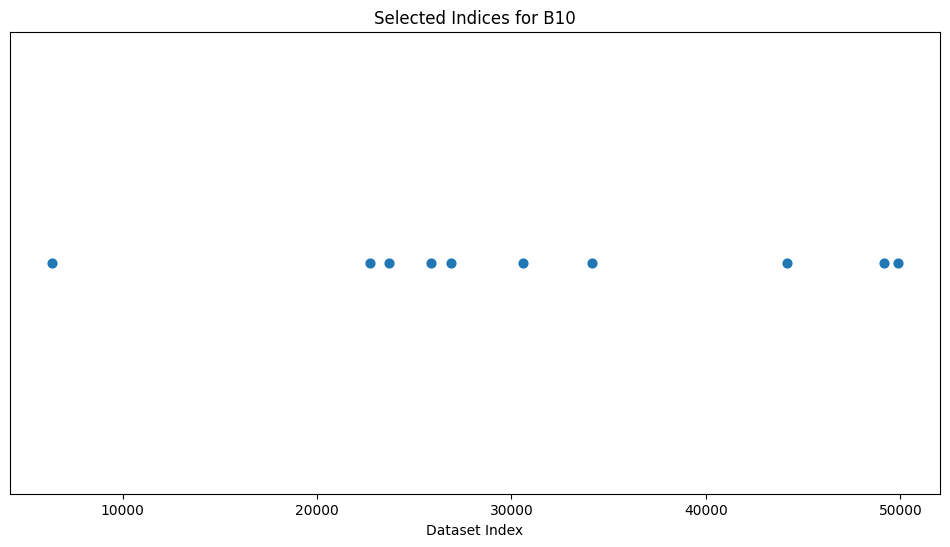

In [ ]:

plt.figure(figsize=(12,6))
plt.scatter(indices, [0]*len(indices), s=40)

plt.title(f"Selected Indices for {Budget}")

plt.yticks([])
plt.xlabel("Dataset Index")
plt.show()

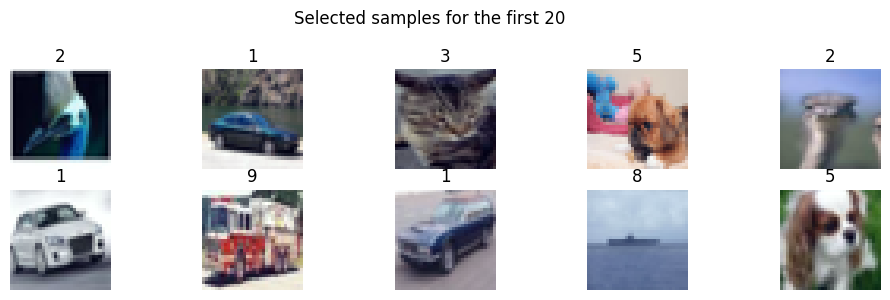

In [ ]:
# CIFAR-10 Images Visualisation 

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    ),
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


plt.figure(figsize=(12,6))
for i, idx in enumerate(indices[:20]):
    img, label = dataset[idx]
    img = img.permute(1,2,0).numpy()
    img = (img * 0.2470 + 0.4914).clip(0,1) # Reverse the normalisation 

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title(f"{label}")
    plt.axis("off")

plt.suptitle(f"Selected samples for the first {limitOfDemonstration}") # be sure to run node above for this 
plt.show()

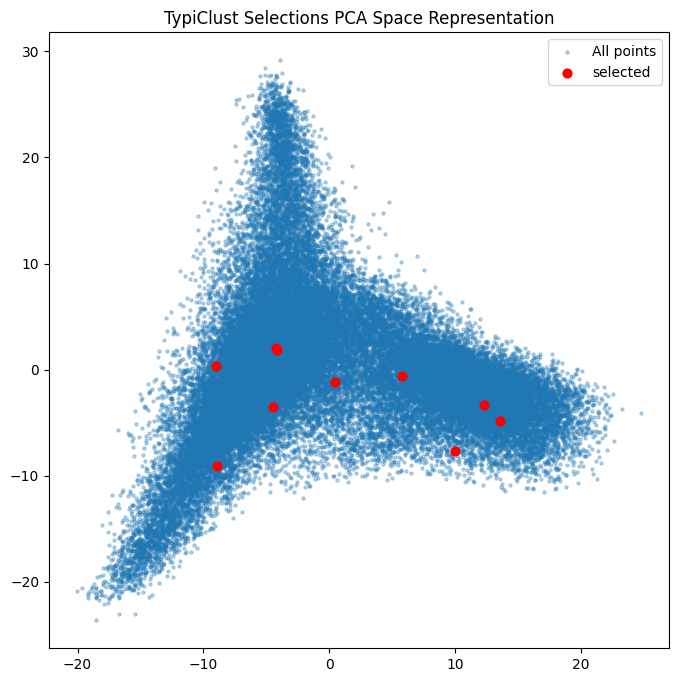

In [17]:
# visualisations in PCA space (manifold)

features = np.load("../TPCRP_Algorithm/modified_budget_results/features.npy")

pca = PCA(n_components=2) # Two dimensional space 
proj = pca.fit_transform(features)

plt.figure(figsize=(8,8))
plt.scatter(proj[:,0], proj[:,1], s=5, alpha=0.3, label="All points")

plt.scatter(proj[indices,0], proj[indices,1], s=40, color="red", label="selected")
plt.legend()

plt.title("TypiClust Selections PCA Space Representation")
plt.show()

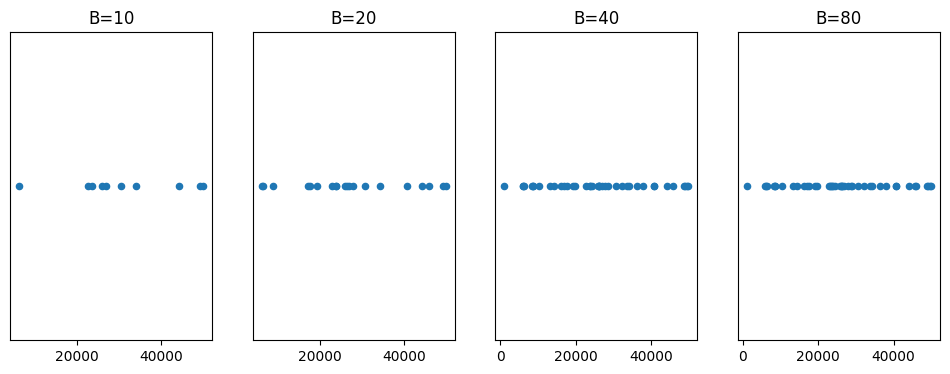

In [19]:
# Comparison across different budgets 

budgets = [10,20,40,80]

paths = [
    f"../TPCRP_Algorithm/modified_budget_results/hdbscan_results/typiclust_HDBSCAN_B{B}.npy"
    for B in budgets 
]

selections = {B : np.load(p) for B,p in zip(budgets, paths)}

plt.figure(figsize=(12,4))
for i, B in enumerate(budgets):
    plt.subplot(1, 4, i+1)
    plt.scatter(selections[B], [0]*len(selections[B]), s=20)
    plt.title(f"B={B}")
    plt.yticks([])
plt.show()